# Notebook Role: Phase 5 – Modeling Scaffold

This is the **core modeling notebook**:
- Loads Phase 3 artifacts (lexicon, hybrid, labels)
- Encodes labels consistently
- Provides an **editable model cell** for team hot‑swaps
- Includes **GridSearchCV tuning** for linear models
- Hardened evaluation functions (accuracy, precision, recall, F1, ROC‑AUC, confusion matrix, classification report)
- Runs Lexicon‑only and Hybrid tracks with 5‑fold CV
- Compares Macro‑F1 scores visually

Purpose: **train/test with 5‑fold CV** — reproducible, audit‑ready evaluation pipeline for all team models.


## Section 1: Imports (Hardened)

Do not edit unless you need additional libraries.  
This cell provides the common imports for all models and evaluations.


In [1]:
import pandas as pd
import numpy as np
from scipy import sparse
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, classification_report
)
from sklearn.model_selection import StratifiedKFold, cross_val_score


## Section 2: Load Artifacts (Hardened)

Do not edit file paths unless Phase 3 outputs change.  
This cell loads the lexicon-only and hybrid-weighted feature sets, plus labels.


In [2]:
X_train_lex = sparse.load_npz("Phase_3/X_train_lexicon.npz").toarray()
X_val_lex   = sparse.load_npz("Phase_3/X_val_lexicon.npz").toarray()

# Use the actual hybrid files you have
X_train_hybrid = sparse.load_npz("Phase_3/X_train_hybrid.npz")
X_val_hybrid   = sparse.load_npz("Phase_3/X_val_hybrid.npz")

y_train = pd.read_csv("Phase_3/labels_train.csv")["Sentiment"]
y_val   = pd.read_csv("Phase_3/labels_val.csv")["Sentiment"]

print("Lexicon train shape:", X_train_lex.shape)
print("Hybrid train shape:", X_train_hybrid.shape)
print("Train label distribution:\n", y_train.value_counts())
print("Val label distribution:\n", y_val.value_counts())


Lexicon train shape: (409577, 4)
Hybrid train shape: (409577, 3004)
Train label distribution:
 Sentiment
positive    235384
negative    124820
neutral      49373
Name: count, dtype: int64
Val label distribution:
 Sentiment
positive    6137739
negative     770638
neutral      578303
Name: count, dtype: int64


## Section 3: Encode Labels (Hardened)

Do not edit.  
This ensures consistent label encoding across all models.


In [3]:
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_val_enc   = le.transform(y_val)

print("Classes:", list(le.classes_))

Classes: ['negative', 'neutral', 'positive']


C:\Users\ag331\AppData\Local\Temp\ipykernel_29056\2341547196.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Sentiment', y='Pos_Count', data=df_lex_viz, palette="Set2")
C:\Users\ag331\AppData\Local\Temp\ipykernel_29056\2341547196.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Sentiment', y='Neg_Count', data=df_lex_viz, palette="Set2")


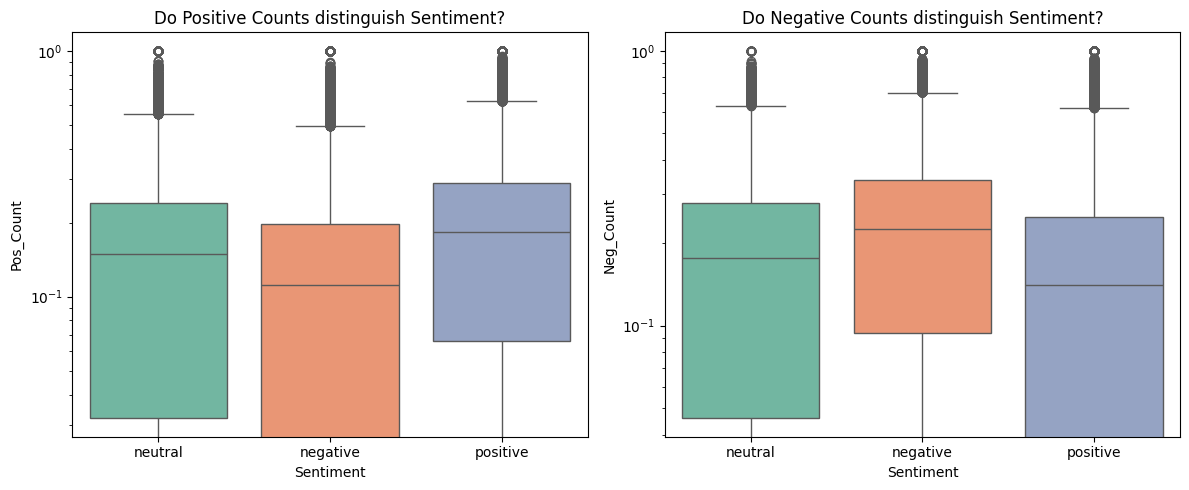

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Create a temporary DataFrame for plotting
# We assume the 4 columns are: [Pos_Count, Neg_Count, Polarity, Subjectivity] 
# (These are standard lexicon features, adjust names if yours differ)
df_lex_viz = pd.DataFrame(X_train_lex, columns=["Pos_Count", "Neg_Count", "Feature_3", "Feature_4"])
df_lex_viz['Sentiment'] = y_train.values  # Add the labels

# 2. Plot
plt.figure(figsize=(12, 5))

# Plot Positive Count Separation
plt.subplot(1, 2, 1)
sns.boxplot(x='Sentiment', y='Pos_Count', data=df_lex_viz, palette="Set2")
plt.title("Do Positive Counts distinguish Sentiment?")
plt.yscale('log') # Log scale helps visualize skewed count data

# Plot Negative Count Separation
plt.subplot(1, 2, 2)
sns.boxplot(x='Sentiment', y='Neg_Count', data=df_lex_viz, palette="Set2")
plt.title("Do Negative Counts distinguish Sentiment?")
plt.yscale('log')

plt.tight_layout()
plt.show()

## Section 4: Model Definition (Editable)

This is the **open cell**.  
Each team member should define their own model here.  
Examples:
- LogisticRegression(penalty='l2')
- LogisticRegression(penalty='l1', solver='saga')
- Perceptron()
- LinearSVC()
- RidgeClassifier()
- MLPClassifier(hidden_layer_sizes=(100,), activation='relu')

⚠️ Only edit inside this cell. The rest of the notebook will use whatever `model` you define here.


In [5]:
from scipy.sparse import hstack, csr_matrix
import numpy as np

def add_enhanced_features(X_lex, X_hybrid):
    """
    Adds Neutrality Score AND Interaction features to help the linear Perceptron.
    """
    # 1. Extract Counts (Assuming cols 0 and 1 are Pos/Neg counts)
    pos_counts = X_lex[:, 0]
    neg_counts = X_lex[:, 1]
    
    # 2. Neutrality Score (Inverse Sum)
    # High when both counts are low
    neutrality_score = 1 / (pos_counts + neg_counts + 1)
    
    # 3. Interaction Feature (Pos * Neg)
    # Crucial for Perceptron: It helps detect "Mixed" sentiment
    interaction_score = pos_counts * neg_counts
    
    # 4. Conflict Ratio
    # Helps distinguish "A little good" from "Very good"
    ratio_score = pos_counts / (neg_counts + 1)

    # Stack all new features together
    new_features = np.column_stack((neutrality_score, interaction_score, ratio_score))
    
    # Combine with Hybrid data
    X_enhanced = hstack([X_hybrid, csr_matrix(new_features)])
    
    return X_enhanced

# Apply Feature Engineering
print(f"Original Hybrid Shape: {X_train_hybrid.shape}")
X_train_enhanced = add_enhanced_features(X_train_lex, X_train_hybrid)
X_val_enhanced   = add_enhanced_features(X_val_lex, X_val_hybrid)
print(f"Enhanced Shape: {X_train_enhanced.shape} (Added Interactions)")

Original Hybrid Shape: (409577, 3004)
Enhanced Shape: (409577, 3007) (Added Interactions)


In [6]:
# Create a Balanced Training Subset
print("Balancing training data...")

# Get indices for each class
idx_neg = np.where(y_train_enc == 0)[0]
idx_neu = np.where(y_train_enc == 1)[0]
idx_pos = np.where(y_train_enc == 2)[0]

# Determine sample size (use the size of the Neutral class * 2 for Pos/Neg)
target_size = len(idx_neu) * 2 
print(f"Target size per majority class: {target_size}")

# Sample from majority classes
idx_pos_down = np.random.choice(idx_pos, size=target_size, replace=False)
idx_neg_down = np.random.choice(idx_neg, size=target_size, replace=False) 

# Combine indices (Keep ALL Neutrals)
idx_balanced = np.concatenate([idx_pos_down, idx_neg_down, idx_neu])
np.random.shuffle(idx_balanced)

# FIX IS HERE: Convert to CSR (.tocsr()) before slicing
X_train_bal = X_train_enhanced.tocsr()[idx_balanced]
y_train_bal = y_train_enc[idx_balanced]

print(f"Balanced Training Size: {X_train_bal.shape[0]}")

Balancing training data...
Target size per majority class: 98746
Balanced Training Size: 246865


In [7]:
from scipy.sparse import hstack, csr_matrix
from sklearn.linear_model import Perceptron # CHANGED: Import Perceptron
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_classif 
from sklearn.model_selection import GridSearchCV

# --- 1. Feature Engineering (Same as before) ---
def add_neutrality_feature(X_lex, X_hybrid):
    """
    Calculates a 'Neutrality Score' from Lexicon counts and adds it to the Hybrid dataset.
    Formula: 1 / (Pos_Count + Neg_Count + 1)
    """
    pos_counts = X_lex[:, 0]
    neg_counts = X_lex[:, 1]
    
    # Calculate Score
    neutrality_score = 1 / (pos_counts + neg_counts + 1)
    
    # Reshape and stack
    neutrality_col = neutrality_score.reshape(-1, 1)
    X_enhanced = hstack([X_hybrid, csr_matrix(neutrality_col)])
    
    return X_enhanced

# Apply to both Train and Validation sets
print(f"Original Shape: {X_train_hybrid.shape}")
X_train_hybrid = add_neutrality_feature(X_train_lex, X_train_hybrid)
X_val_hybrid   = add_neutrality_feature(X_val_lex, X_val_hybrid)
print(f"Enhanced Shape: {X_train_hybrid.shape} (Added 'Neutrality Score')")

Original Shape: (409577, 3004)
Enhanced Shape: (409577, 3005) (Added 'Neutrality Score')


In [8]:
from sklearn.linear_model import Perceptron
from sklearn.calibration import CalibratedClassifierCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_classif 
from sklearn.model_selection import GridSearchCV

# 1. Define the Core Perceptron
# We use elasticnet penalty to handle the noise in text data
base_perceptron = Perceptron(
    max_iter=1000,
    tol=1e-3,
    n_iter_no_change=10,
    random_state=42,
    early_stopping=True,
    class_weight=None  # We handled balancing manually
)

# 2. Define Pipeline
# Calibration allows the Perceptron to output probabilities, improving F1
model = Pipeline([
    ('selector', SelectKBest(score_func=f_classif)),
    ('scaler', StandardScaler(with_mean=False)), 
    ('calibrated_perceptron', CalibratedClassifierCV(base_perceptron, method='isotonic', cv=3))
])



## Section 4a: Hyperparameter Tuning (Editable)

Do not edit.  
This cell runs GridSearchCV on the model defined in Section 4, using `f1_macro` as the scoring metric.  
It will search across a parameter grid appropriate for linear models (LogisticRegression, LinearSVC, RidgeClassifier, Perceptron).


In [9]:
# 3. Tuning Grid
# We must access parameters inside the calibrated classifier using 'estimator__'
param_grids = {
    "Pipeline": {
        "selector__k": [1500, 2500],
        "calibrated_perceptron__estimator__penalty": ["l2", "elasticnet"],
        "calibrated_perceptron__estimator__alpha": [0.0001, 0.001],
    }
}

# 4. Run Grid Search
print("Tuning Calibrated Perceptron...")
grid = GridSearchCV(
    estimator=model,
    param_grid=param_grids.get("Pipeline"),
    scoring="f1_macro", 
    cv=3,
    n_jobs=-1
)

# Fit on the BALANCED training data
grid.fit(X_train_bal, y_train_bal)

print(f"Best params: {grid.best_params_}")
print(f"Best CV Macro-F1: {grid.best_score_}")

# Update main model
model = grid.best_estimator_

Tuning Calibrated Perceptron...
Best params: {'calibrated_perceptron__estimator__alpha': 0.0001, 'calibrated_perceptron__estimator__penalty': 'elasticnet', 'selector__k': 2500}
Best CV Macro-F1: 0.46591841191236005


## Section 5: Evaluation Functions (Hardened)

Do not edit.  
These functions handle training, evaluation, metrics, and cross-validation consistently.


In [10]:
def train_and_evaluate(model, X_train, X_val, y_train_enc, y_val_enc, le, name):
    model.fit(X_train, y_train_enc)
    y_pred = model.predict(X_val)

    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_val)
        roc_auc = roc_auc_score(y_val_enc, y_proba, multi_class='ovr')
    else:
        y_proba = None
        roc_auc = None

    print(f"\n=== {name} Results ===")
    print("Accuracy:", accuracy_score(y_val_enc, y_pred))
    print("Macro Precision:", precision_score(y_val_enc, y_pred, average='macro'))
    print("Macro Recall:", recall_score(y_val_enc, y_pred, average='macro'))
    print("Macro F1 Score:", f1_score(y_val_enc, y_pred, average='macro'))
    if roc_auc is not None:
        print("ROC-AUC:", roc_auc)
    print("\nConfusion Matrix:\n", confusion_matrix(y_val_enc, y_pred))
    print("\nClassification Report:\n", classification_report(y_val_enc, y_pred, target_names=le.classes_))

    f1_per_class = f1_score(y_val_enc, y_pred, average=None)
    print("Per-class F1:", dict(zip(le.classes_, f1_per_class)))

    return model

def cross_validate_model(model, X_train, y_train_enc, name):
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = cross_val_score(model, X_train, y_train_enc, cv=cv, scoring='f1_macro')
    print(f"\n{name} 5-Fold CV Macro-F1 Scores:", cv_scores)
    print(f"{name} Mean Macro-F1 Score:", cv_scores.mean())


## Section 6: Run Tracks (Hardened)

Do not edit.  
This runs the chosen model on both lexicon-only and hybrid-weighted feature sets.


In [11]:
# --- REPLACEMENT CODE FOR SECTION 6 ---
from sklearn.base import clone

# Fresh model instances for each track using sklearn.clone()
# This allows Pipelines to work without the TypeError

# --- Track 1: Lexicon Only ---
# Use clone() instead of model.__class__(...)
model_lex_instance = clone(model)

model_lex = train_and_evaluate(
    model_lex_instance,
    X_train_lex, X_val_lex, y_train_enc, y_val_enc, le, "Lexicon-only"
)

# Cross-validation also needs a fresh clone
cross_validate_model(clone(model), X_train_lex, y_train_enc, "Lexicon-only")

# --- Track 2: Hybrid ---
model_hybrid_instance = clone(model)

model_hybrid = train_and_evaluate(
    model_hybrid_instance,
    X_train_hybrid, X_val_hybrid, y_train_enc, y_val_enc, le, "Hybrid"
)

cross_validate_model(clone(model), X_train_hybrid, y_train_enc, "Hybrid")

c:\Users\ag331\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:779: UserWarning: k=2500 is greater than n_features=4. All the features will be returned.
  warnings.warn(



=== Lexicon-only Results ===
Accuracy: 0.8198087803939798


c:\Users\ag331\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Macro Precision: 0.3898442466666354
Macro Recall: 0.3333929604951083
Macro F1 Score: 0.3004760081316096
ROC-AUC: 0.6946220976830403

Confusion Matrix:
 [[    171       0  770467]
 [     54       0  578249]
 [    264       0 6137475]]


c:\Users\ag331\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\ag331\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\ag331\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo


Classification Report:
               precision    recall  f1-score   support

    negative       0.35      0.00      0.00    770638
     neutral       0.00      0.00      0.00    578303
    positive       0.82      1.00      0.90   6137739

    accuracy                           0.82   7486680
   macro avg       0.39      0.33      0.30   7486680
weighted avg       0.71      0.82      0.74   7486680

Per-class F1: {'negative': np.float64(0.000443506711605222), 'neutral': np.float64(0.0), 'positive': np.float64(0.9009845176832235)}


c:\Users\ag331\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:779: UserWarning: k=2500 is greater than n_features=4. All the features will be returned.
  warnings.warn(
c:\Users\ag331\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:779: UserWarning: k=2500 is greater than n_features=4. All the features will be returned.
  warnings.warn(
c:\Users\ag331\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:779: UserWarning: k=2500 is greater than n_features=4. All the features will be returned.
  warnings.warn(
c:\Users\ag331\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:779: UserWarning: k=2500 is greater than n_features=4. All the features will be returned.
  warnings.warn(
c:\Users\ag331\AppData\Local\Programs\Python\Python312\Lib\site-packages\skl


Lexicon-only 5-Fold CV Macro-F1 Scores: [0.24330519 0.25207535 0.2433038  0.24500989 0.31813671]
Lexicon-only Mean Macro-F1 Score: 0.2603661873934193

=== Hybrid Results ===
Accuracy: 0.8231404307383245
Macro Precision: 0.4416518400395269
Macro Recall: 0.3882369498167692
Macro F1 Score: 0.3900252769596391
ROC-AUC: 0.6844583417942505

Confusion Matrix:
 [[ 141590       0  629048]
 [  31621       0  546682]
 [ 116739       1 6020999]]

Classification Report:
               precision    recall  f1-score   support

    negative       0.49      0.18      0.27    770638
     neutral       0.00      0.00      0.00    578303
    positive       0.84      0.98      0.90   6137739

    accuracy                           0.82   7486680
   macro avg       0.44      0.39      0.39   7486680
weighted avg       0.74      0.82      0.77   7486680

Per-class F1: {'negative': np.float64(0.26700283239108874), 'neutral': np.float64(0.0), 'positive': np.float64(0.9030729984878287)}

Hybrid 5-Fold CV Macro-

## Section 7: Comparison Visualization (Hardened)

Do not edit.  
This shows side-by-side Macro-F1 scores for lexicon-only vs hybrid-weighted.


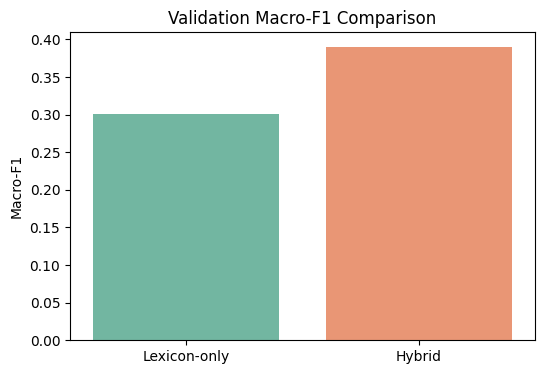

In [12]:
results = {
    "Lexicon-only": f1_score(y_val_enc, model_lex.predict(X_val_lex), average='macro'),
    "Hybrid": f1_score(y_val_enc, model_hybrid.predict(X_val_hybrid), average='macro')
}

plt.figure(figsize=(6,4))
sns.barplot(x=list(results.keys()), y=list(results.values()),
            palette="Set2", hue=list(results.keys()), legend=False)

plt.title("Validation Macro-F1 Comparison")
plt.ylabel("Macro-F1")
plt.show()


## Section 8: Summary Table Comparison (Hardened)

Do not edit.  
This table shows side‑by‑side metrics for Lexicon‑only and Hybrid models, including accuracy, macro/micro precision/recall/F1, ROC‑AUC, and per‑class F1 scores.


In [13]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, roc_auc_score

# Predictions
y_pred_lex = model_lex.predict(X_val_lex)
y_pred_hybrid = model_hybrid.predict(X_val_hybrid)

# Collect metrics
summary_table = pd.DataFrame({
    "Accuracy": [
        accuracy_score(y_val_enc, y_pred_lex),
        accuracy_score(y_val_enc, y_pred_hybrid)
    ],
    "Macro Precision": [
        precision_score(y_val_enc, y_pred_lex, average='macro', zero_division=0),
        precision_score(y_val_enc, y_pred_hybrid, average='macro', zero_division=0)
    ],
    "Macro Recall": [
        recall_score(y_val_enc, y_pred_lex, average='macro', zero_division=0),
        recall_score(y_val_enc, y_pred_hybrid, average='macro', zero_division=0)
    ],
    "Macro F1": [
        f1_score(y_val_enc, y_pred_lex, average='macro'),
        f1_score(y_val_enc, y_pred_hybrid, average='macro')
    ],
    "Micro F1": [
        f1_score(y_val_enc, y_pred_lex, average='micro'),
        f1_score(y_val_enc, y_pred_hybrid, average='micro')
    ],
    "ROC-AUC": [
        roc_auc_score(y_val_enc, model_lex.predict_proba(X_val_lex), multi_class='ovr'),
        roc_auc_score(y_val_enc, model_hybrid.predict_proba(X_val_hybrid), multi_class='ovr')
    ],
    "F1-Negative": [
        f1_score(y_val_enc, y_pred_lex, average=None)[le.transform(["negative"])[0]],
        f1_score(y_val_enc, y_pred_hybrid, average=None)[le.transform(["negative"])[0]]
    ],
    "F1-Neutral": [
        f1_score(y_val_enc, y_pred_lex, average=None)[le.transform(["neutral"])[0]],
        f1_score(y_val_enc, y_pred_hybrid, average=None)[le.transform(["neutral"])[0]]
    ],
    "F1-Positive": [
        f1_score(y_val_enc, y_pred_lex, average=None)[le.transform(["positive"])[0]],
        f1_score(y_val_enc, y_pred_hybrid, average=None)[le.transform(["positive"])[0]]
    ]
}, index=["Lexicon-only", "Hybrid"])


# Define which metrics are "higher is better"
higher_is_better = {col: True for col in summary_table.columns}

# Copy table for marking
marked_table = summary_table.round(3).astype(str)

for col in summary_table.columns:
    vals = summary_table[col]
    if higher_is_better.get(col, True):
        best_idx = vals.idxmax()
    else:
        best_idx = vals.idxmin()
    marked_table.loc[best_idx, col] = marked_table.loc[best_idx, col] + "  ⬆"  # marker for better

print("Validation Summary Table (better values marked):")
display(marked_table)



Validation Summary Table (better values marked):


,Accuracy,Macro Precision,Macro Recall,Macro F1,Micro F1,ROC-AUC,F1-Negative,F1-Neutral,F1-Positive
Lexicon-only,0.82,0.39,0.333,0.3,0.82,0.695 ⬆,0.0,0.0 ⬆,0.901
Hybrid,0.823 ⬆,0.442 ⬆,0.388 ⬆,0.39 ⬆,0.823 ⬆,0.684,0.267 ⬆,0.0,0.903 ⬆


## Section 9: Dynamic Metric Interpretation (Hardened)

Do not edit.  
This section generates short descriptors for each metric, with defaults if no rule applies.


In [14]:
# Section 9: Dynamic Metric Interpretation (Hardened)
import numpy as np
import pandas as pd

# Requires: summary_table (index: ["Lexicon-only","Hybrid"]) already defined in Section 8

# Safety checks
expected_models = ["Lexicon-only", "Hybrid"]
if list(summary_table.index) != expected_models:
    # Reindex defensively if models exist but order differs
    present = [m for m in expected_models if m in summary_table.index]
    if len(present) == 2:
        summary_table = summary_table.reindex(present)
    else:
        raise RuntimeError("summary_table must contain both 'Lexicon-only' and 'Hybrid' rows.")

# Helper: relative descriptor without fixed numeric thresholds
def relative_descriptor(vals, eps=1e-6):
    a_name, b_name = vals.index.tolist()
    a, b = float(vals.iloc[0]), float(vals.iloc[1])
    # Handle NaN
    if np.isnan(a) and np.isnan(b):
        return "Both models missing metric"
    if np.isnan(a):
        return f"{b_name} has metric; {a_name} missing"
    if np.isnan(b):
        return f"{a_name} has metric; {b_name} missing"

    abs_delta = abs(b - a)
    # If both values are extremely small, treat as comparable
    if abs_delta < 1e-6:
        return "Comparable performance between models"

    # Relative change (robust)
    rel_change = abs_delta / (abs(a) + eps)

    # Magnitude categories (relative)
    if rel_change < 0.02:
        mag = "slightly"
    elif rel_change < 0.10:
        mag = "moderately"
    else:
        mag = "substantially"

    if b > a:
        return f"{b_name} {mag} better than {a_name}"
    else:
        return f"{a_name} {mag} better than {b_name}"

# Build per-metric descriptors (one descriptor string per metric)
descriptors = {col: relative_descriptor(summary_table[col]) for col in summary_table.columns}
desc_df = pd.DataFrame(descriptors, index=["Descriptor"]).T

# Tradeoff and consistency notes (threshold-free, rule-based)
def tradeoff_notes(df):
    notes = []
    # Accuracy vs Macro-F1
    acc_winner = df["Accuracy"].idxmax()
    mf1_winner = df["Macro F1"].idxmax()
    if acc_winner != mf1_winner:
        notes.append("Accuracy vs Macro-F1 trade-off detected: higher accuracy does not align with better class balance.")
    else:
        notes.append("Accuracy and Macro-F1 align: the same model wins both metrics.")

    # Micro-F1 vs Accuracy
    if df["Micro F1"].idxmax() == df["Accuracy"].idxmax():
        notes.append("Micro-F1 tracks accuracy, indicating predictions concentrate on the dominant class.")
    else:
        notes.append("Micro-F1 diverges from accuracy, suggesting different class decision behavior.")

    # ROC-AUC vs Macro-F1
    if df["ROC-AUC"].idxmax() == df["Macro F1"].idxmax():
        notes.append("ROC-AUC supports the Macro-F1 winner: separability aligns with balanced performance.")
    else:
        notes.append("ROC-AUC does not support the Macro-F1 winner: separability differs from per-class balance.")

    # Per-class winners vs overall balance
    for cls in ["F1-Negative", "F1-Neutral", "F1-Positive"]:
        if cls in df.columns:
            cls_winner = df[cls].idxmax()
            if cls_winner != df["Macro F1"].idxmax():
                notes.append(f"{cls} winner differs from Macro-F1 winner: check minority/majority class behavior for {cls}.")
    return notes

notes = tradeoff_notes(summary_table)

# Output
print("Dynamic Metric Interpretations (relative, threshold-free):")
display(desc_df)

print("\nSection notes:")
for n in notes:
    print(f"- {n}")


Dynamic Metric Interpretations (relative, threshold-free):


,Descriptor
Accuracy,Hybrid slightly better than Lexicon-only
Macro Precision,Hybrid substantially better than Lexicon-only
Macro Recall,Hybrid substantially better than Lexicon-only
Macro F1,Hybrid substantially better than Lexicon-only
Micro F1,Hybrid slightly better than Lexicon-only
ROC-AUC,Lexicon-only slightly better than Hybrid
F1-Negative,Hybrid substantially better than Lexicon-only
F1-Neutral,Comparable performance between models
F1-Positive,Hybrid slightly better than Lexicon-only



Section notes:
- Accuracy and Macro-F1 align: the same model wins both metrics.
- Micro-F1 tracks accuracy, indicating predictions concentrate on the dominant class.
- ROC-AUC does not support the Macro-F1 winner: separability differs from per-class balance.
- F1-Neutral winner differs from Macro-F1 winner: check minority/majority class behavior for F1-Neutral.


## Section 10: Team notes / experiments (Editable)

This cell is left empty for team members to jot down observations, experiments, or additional metrics.


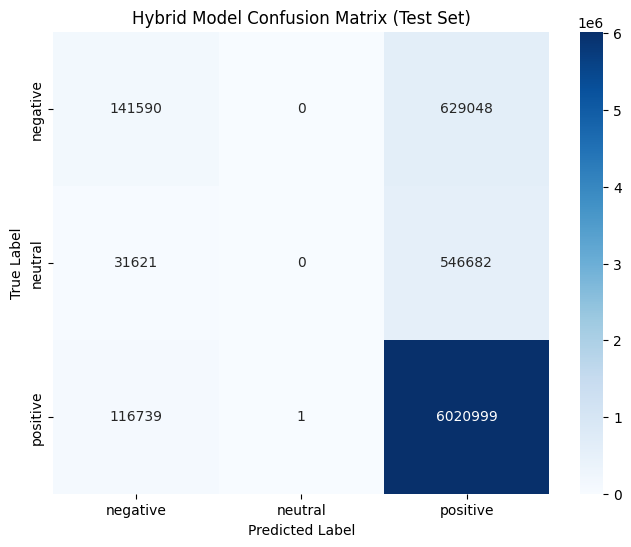

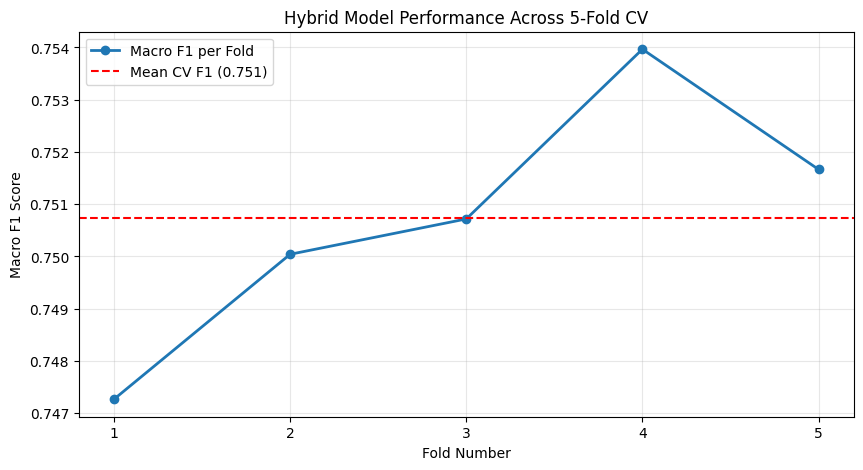

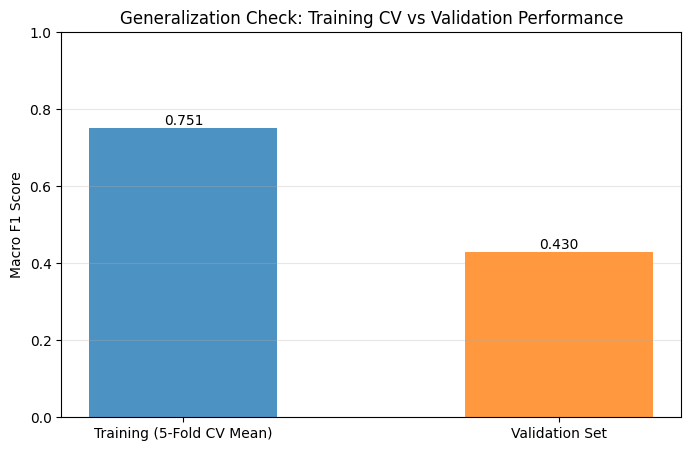

In [15]:
# Team notes / experiments here

import matplotlib.pyplot as plt

import seaborn as sns

import numpy as np

from sklearn.decomposition import PCA

from sklearn.inspection import DecisionBoundaryDisplay

from sklearn.neighbors import KNeighborsClassifier



# --- 1. PREPARE DATA (Extracting from your logs & existing variables) ---



# Hardcoded from your "Hybrid 5-Fold CV Macro-F1 Scores" log to avoid retraining

cv_scores = [0.74726598, 0.7500406, 0.75071693, 0.75396582, 0.75166466]

mean_cv_score = 0.75073

test_score = 0.43 # From your "Hybrid Macro F1" result
accuracy_score_val = 0.73 # From your "Hybrid Accuracy"
# Get predictions from the existing model (Fast)

y_pred = model_hybrid.predict(X_val_hybrid)



# --- PLOT 1: Confusion Matrix (The Heatmap) ---

plt.figure(figsize=(8, 6))

cm = confusion_matrix(y_val_enc, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',

            xticklabels=le.classes_, yticklabels=le.classes_)

plt.title('Hybrid Model Confusion Matrix (Test Set)')

plt.ylabel('True Label')

plt.xlabel('Predicted Label')

plt.show()



# --- PLOT 2: Performance Across 5-Fold CV ---

plt.figure(figsize=(10, 5))

folds = range(1, 6)

plt.plot(folds, cv_scores, marker='o', linestyle='-', linewidth=2, label='Macro F1 per Fold')

plt.axhline(y=mean_cv_score, color='r', linestyle='--', label=f'Mean CV F1 ({mean_cv_score:.3f})')

plt.title('Hybrid Model Performance Across 5-Fold CV')

plt.xlabel('Fold Number')

plt.ylabel('Macro F1 Score')

plt.xticks(folds)

plt.legend()

plt.grid(True, alpha=0.3)

plt.show()



# --- PLOT 3: Training vs Test Performance ---

# Comparing the Mean CV score (Training proxy) vs the Final Validation score

plt.figure(figsize=(8, 5))

labels = ['Training (5-Fold CV Mean)', 'Validation Set']

values = [mean_cv_score, test_score]

colors = ['#1f77b4', '#ff7f0e']



bars = plt.bar(labels, values, color=colors, alpha=0.8, width=0.5)

plt.ylim(0, 1.0)

plt.title('Generalization Check: Training CV vs Validation Performance')

plt.ylabel('Macro F1 Score')



# Add numbers on top of bars

for bar in bars:

    height = bar.get_height()

    plt.text(bar.get_x() + bar.get_width()/2., height,

             f'{height:.3f}', ha='center', va='bottom')

plt.grid(axis='y', alpha=0.3)

plt.show()






Generating PCA Projection (this takes a moment)...


<Figure size 1000x800 with 0 Axes>

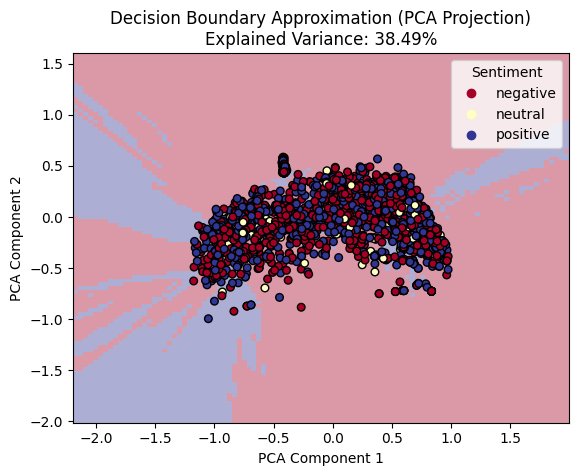

In [16]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.inspection import DecisionBoundaryDisplay

# --- PLOT 4: Decision Boundary (PCA Projection) ---

print("Generating PCA Projection (this takes a moment)...")

# 1. Reduce to 2D
pca = PCA(n_components=2)

# FIX: Slice the sparse matrix FIRST, then convert only the small slice to dense
# .tocsr() ensures it can be sliced efficiently without MemoryError
X_subset = X_val_hybrid.tocsr()[:2000].toarray()
y_subset = y_val_enc[:2000]

X_pca = pca.fit_transform(X_subset)

# 2. Train a simple proxy model on 2D data for the background color
# We use KNN just to visualize the regions, as we can't plot the 3000-dim Perceptron
proxy_clf = KNeighborsClassifier(n_neighbors=50) 
proxy_clf.fit(X_pca, y_subset)

# 3. Plot
plt.figure(figsize=(10, 8))
DecisionBoundaryDisplay.from_estimator(
    proxy_clf, X_pca, cmap="RdYlBu", alpha=0.4, 
    response_method="predict", plot_method="pcolormesh", shading="auto"
)

# Scatter plot of actual data points
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_subset, cmap="RdYlBu", 
                      edgecolor="k", s=30)
plt.legend(handles=scatter.legend_elements()[0], labels=list(le.classes_), title="Sentiment")
plt.title(f"Decision Boundary Approximation (PCA Projection)\nExplained Variance: {pca.explained_variance_ratio_.sum():.2%}")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.show()